In [266]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

from sklearn.metrics import root_mean_squared_error

import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

from src.features.feature_utils import *

In this notebook, I evaluate the performance of four load forecasting models with increasing levels of feature engineering and model complexity:

1. **Baseline Linear**
A linear regression model using minimally transformed features. These include month of year and hour of day (both encoded as cyclic variables), day of month, average temperature across the five sites, and average global horizontal irradiance (GHI) across the five sites.

2. **Engineered Linear**
A linear regression model using engineered and selected features that improve performance, as measured by RMSE (see load_forecasting/notebooks/feature_design.ipynb). In addition to cyclic hour of day, month of year, and day of month, this model includes a 6-hour rolling average temperature, average GHI across the five sites, binary indicators for weekends and notable days, cooling degree hours (CDH), heating degree hours (HDH), and lagged load at 1, 2, 3, and 24 hours.

3. **Complete XGBoost**
A gradient-boosted decision tree model (XGBoost) trained on an exhaustive feature set. This includes all features from the Engineered Linear model, as well as rolling temperature averages over 3 and 24 hours, CDH and HDH aggregated over 3, 6, and 24 hours, and additional load lags at 6, 12, 48, and 168 hours.

4. **Linear + XGBoost**
A hybrid model in which the Engineered Linear model is first trained, and a second XGBoost model is then trained to predict its residuals using the exhaustive feature set described above. Final predictions are obtained by summing the linear prediction and the residual correction.

In [269]:
raw_train_loc = "../data/raw/train.xlsx"
raw_test_loc = "../data/raw/test.xlsx"

raw_train = pd.read_excel(raw_train_loc)
raw_test = pd.read_excel(raw_test_loc)

In [270]:
# Because some model use up to 168 lag values, I prepend 168 values from the training set to the test set (as both sets are chronologically continuous).
# This ensures that when lagged values are generated, there will be no missing values for dates in the test set.

raw_train_lag_week = raw_train[-168:]

raw_test_with_lag_week = pd.concat([raw_train_lag_week, raw_test], axis = 0)

test_transformed = complete_df_transformer(raw_test_with_lag_week)

In [273]:
test_transformed.head()

,Year,Month,Day,Hour,Load,Site-1 Temp,Site-2 Temp,Site-3 Temp,Site-4 Temp,Site-5 Temp,...,Load_lag_1h,Load_lag_2h,Load_lag_3h,Load_lag_6h,Load_lag_12h,Load_lag_24h,Load_lag_48h,Load_lag_168h,is_weekend,is_notable_day
0,2022,1,1,0,2064,54.14,52.70,48.74,54.86,51.44,...,2118.0,2229.0,2348.0,2644.0,2184.0,1968.0,2203.0,2008.0,1,1
1,2022,1,1,1,1975,53.78,51.98,48.74,54.14,51.08,...,2064.0,2118.0,2229.0,2545.0,2193.0,1916.0,2125.0,1887.0,1,1
2,2022,1,1,2,1900,51.44,50.36,48.20,53.24,49.82,...,1975.0,2064.0,2118.0,2449.0,2280.0,1851.0,2115.0,1814.0,1,1
3,2022,1,1,3,1829,50.00,50.54,48.74,51.62,48.02,...,1900.0,1975.0,2064.0,2348.0,2359.0,1799.0,2092.0,1776.0,1,1
4,2022,1,1,4,1828,51.98,50.54,49.64,51.62,49.28,...,1829.0,1900.0,1975.0,2229.0,2513.0,1856.0,1997.0,1776.0,1,1


In [275]:
with open('../trained_models/baseline_linear.pkl', 'rb') as file:
    baseline_linear = pickle.load(file)

with open('../trained_models/engineered_linear.pkl', 'rb') as file:
    engineered_linear = pickle.load(file)

with open('../trained_models/complete_xgb.pkl', 'rb') as file:
    complete_xgb = pickle.load(file)

with open('../trained_models/lin_xgb_linear_component.pkl', 'rb') as file:
    lin_xgb_linear_component = pickle.load(file)

with open('../trained_models/lin_xgb_xgboost_component.pkl', 'rb') as file:
    lin_xgb_xgboost_component = pickle.load(file)


In [277]:
splits_df_loc = "../data/splits/split_bounds.csv"
splits_df = pd.read_csv(splits_df_loc)

def cv_rmse(model_name, input_df):

    match model_name:
        case "baseline_linear":
            complete_df = baseline_df_transformer(input_df)
            model = LinearRegression()
            
        case "engineered_linear":
            complete_df = engineered_df_transformer(input_df)
            model = LinearRegression()
            
        case "complete_xgb":
            complete_df = complete_df_transformer(input_df)
            model = XGBRegressor(objective='reg:squarederror', n_estimators = 200, learning_rate = 0.1, max_depth = 3, subsample = 0.8)
            
        case "lin_xgb":
            complete_df = complete_df_transformer(input_df)

            lin_features = ["Hour_sin", "Hour_cos", "Month", "Day", "temp_6h", "avg_region_ghi", "is_weekend", "is_notable_day", "CDH", "HDH", "Load_lag_1h", "Load_lag_2h", "Load_lag_3h", "Load_lag_24h"]
            
            model = LinearRegression()
            residual_model = XGBRegressor( objective='reg:squarederror', n_estimators = 800, learning_rate = 0.05, max_depth = 4, subsample = 0.8)

    rmse_list = []

    for i in range(1, 6):
        split = f"split_{i}"
        
        row = splits_df[splits_df["split"] == split].iloc[0]
        train_start_date = row["train_start_date"]
        train_end_date = row["train_end_date"]
        val_start_date = row["val_start_date"]
        val_end_date = row["val_end_date"]
        
        train_mask = (complete_df["timestamp"] >= train_start_date) & (complete_df["timestamp"] < train_end_date)
        val_mask = (complete_df["timestamp"] >= val_start_date) & (complete_df["timestamp"] < val_end_date)


        train_split = complete_df[train_mask].drop(columns=["timestamp"])
        val_split = complete_df[val_mask].drop(columns=["timestamp"])

        
        X_train = train_split.drop(columns=["Load"])
        y_train = train_split["Load"]
        
        X_val = val_split.drop(columns=["Load"])
        y_val = val_split["Load"]

        if model_name == "lin_xgb":
            model.fit(X_train[lin_features], y_train)
            residuals_train = y_train - model.predict(X_train[lin_features])
            residual_model.fit(X_train, residuals_train)
           
            y_pred = model.predict(X_val[lin_features]) + residual_model.predict(X_val)
            
        else:
           model.fit(X_train, y_train)
           y_pred = model.predict(X_val)

        rmse = root_mean_squared_error(y_val, y_pred)
    
        rmse_list.append(rmse)
        
    return np.mean(rmse_list), np.std(rmse_list)

def generate_all_predictions(model_name, df):
    
    match model_name:
        case "baseline_linear":
            predict_df = df[["Month_sin", "Month_cos", "Day", "Hour_sin", "Hour_cos", "avg_region_temp", "avg_region_ghi"]]
            return baseline_linear.predict(predict_df)
            
        case "engineered_linear":
            predict_df = df[["Hour_sin", "Hour_cos", "Month", "Day", "temp_6h", "avg_region_ghi", "is_weekend", "is_notable_day", "CDH", "HDH", "Load_lag_1h", "Load_lag_2h", "Load_lag_3h", "Load_lag_24h"]]
            return engineered_linear.predict(predict_df)
            
        case "complete_xgb":
            predict_df = df.drop(columns = ["Load", "timestamp"])
            return complete_xgb.predict(predict_df)
            
        case "lin_xgb":
            predict_df = df.drop(columns = ["Load", "timestamp"])

            lin_features = ["Hour_sin", "Hour_cos", "Month", "Day", "temp_6h", "avg_region_ghi", "is_weekend", "is_notable_day", "CDH", "HDH", "Load_lag_1h", "Load_lag_2h", "Load_lag_3h", "Load_lag_24h"]
            
            linear = lin_xgb_linear_component.predict(predict_df[lin_features])
            
            residual = lin_xgb_xgboost_component.predict(predict_df)
            
            return linear + residual

        case _:
            raise ValueError(f"Invalid model name: {model_name}")


In [279]:
errors_dict = {"model_name": ["baseline_linear", "engineered_linear", "complete_xgb", "lin_xgb"], "train_error" : [], "validation_error": [], "validation_std": [], "test_error": []}

model_df_transformers = [baseline_df_transformer, engineered_df_transformer, complete_df_transformer, complete_df_transformer]

baseline_preds = pd.DataFrame(generate_all_predictions("baseline_linear", baseline_df_transformer(raw_test)), columns = ["baseline_linear_load"])

eng_lin_preds = pd.DataFrame(generate_all_predictions("engineered_linear", test_transformed), columns = ["engineered_linear_load"])

xgb_preds = pd.DataFrame(generate_all_predictions("complete_xgb", test_transformed), columns = ["complete_xgb_load"])

lin_xgb_preds = pd.DataFrame(generate_all_predictions("lin_xgb", test_transformed), columns = ["lin_xgb_load"])

complete_predictions = pd.concat([test_transformed, baseline_preds, eng_lin_preds, xgb_preds, lin_xgb_preds], axis = 1)
complete_predictions = complete_predictions[["timestamp", "Load", "baseline_linear_load", "engineered_linear_load", "complete_xgb_load", "lin_xgb_load", "avg_region_temp", "is_weekend"]].rename(columns = {"Load": "Actual Load"})

for model_name, transformer in zip(errors_dict["model_name"], model_df_transformers):

    train_error = root_mean_squared_error(generate_all_predictions(model_name, transformer(raw_train)), transformer(raw_train)["Load"])

    validation_error, validation_std = cv_rmse(model_name, raw_train)

    test_error = root_mean_squared_error(complete_predictions["Actual Load"], complete_predictions[model_name + "_load"])

    errors_dict["train_error"].append(train_error)
    errors_dict["validation_error"].append(validation_error)
    errors_dict["validation_std"].append(validation_std)
    errors_dict["test_error"].append(test_error)

errors_df = pd.DataFrame(errors_dict)


In [285]:
errors_df

,model_name,train_error,validation_error,validation_std,test_error
0,baseline_linear,293.190918,388.492094,192.333498,332.202720
1,engineered_linear,57.006376,59.096682,4.598002,68.152193
2,complete_xgb,45.804598,56.109125,6.296292,68.881676
3,lin_xgb,53.643832,46.863035,4.105250,66.274391


First, the baseline linear model performs substantially worse than all other models across training, validation, and testing. Its relatively large validation standard deviation indicates that it is also the least stable across time, suggesting that minimally transformed calendar and weather features are insufficient to reliably capture load dynamics.

Second, feature engineering dramatically improves linear model performance. The engineered linear model reduces validation RMSE by nearly an order of magnitude relative to the baseline and exhibits low variability across cross-validation splits. This indicates that the engineered features (particularly lagged load, degree-hour variables, and temporal indicators) capture the dominant structure in the load signal and generalize well out of sample.

Third, while the complete XGBoost model achieves a lower training error and slightly lower average validation error than the engineered linear model, it exhibits higher validation variability and does not improve test-set performance. This suggests that the additional nonlinear flexibility allows the model to fit patterns in the training data that do not consistently transfer to unseen periods, resulting in mild overfitting.

Finally, the combined Linear + XGBoost residual model provides the strongest overall performance. It achieves the lowest validation and test errors while also maintaining low variability across cross-validation splits. This indicates that the linear model captures the majority of the predictable structure in the data, while XGBoost is most effective when constrained to learning residual nonlinear effects rather than the full load signal.

Overall, these results suggest that model structure matters as much as model complexity: a strong linear baseline with carefully engineered features generalizes better than a fully flexible tree-based model, and selectively applying nonlinear modeling to residuals yields the most robust performance.

In [292]:
top_load_days_dict = {"model_name": ["baseline_linear", "engineered_linear", "complete_xgb", "lin_xgb"], "top_ten_percent_load_days": [], "top_five_percent_load_days": [], "top_one_percent_load_days": []}

top_load_percents = [("top_ten_percent_load_days", 0.9), ("top_five_percent_load_days", 0.95), ("top_one_percent_load_days", 0.99)]

for model_name in top_load_days_dict["model_name"]:
    
    for percent_name, percent_val in top_load_percents:

        top_n_percent_load_val = complete_predictions["Actual Load"].quantile(percent_val) 
        top_n_percent_load_val_df = complete_predictions[complete_predictions["Actual Load"] >= top_n_percent_load_val]
        
        top_load_days_dict[percent_name].append(root_mean_squared_error(top_n_percent_load_val_df["Actual Load"], top_n_percent_load_val_df[model_name+"_load"]))

top_load_days_df = pd.DataFrame(top_load_days_dict)

In [293]:
top_load_days_df

,model_name,top_ten_percent_load_days,top_five_percent_load_days,top_one_percent_load_days
0,baseline_linear,673.283953,841.574738,1184.250696
1,engineered_linear,77.319565,86.758232,107.431603
2,complete_xgb,109.594112,135.908608,236.256422
3,lin_xgb,74.747158,83.775396,103.488475


The table above reports model performance on high-load days, evaluated by RMSE over the top 10%, 5%, and 1% of actual load values in the held-out test year. As expected, all models exhibit increasing error as the evaluation focuses on more extreme demand levels, reflecting the inherent difficulty of forecasting rare peak events. However, the magnitude of this degradation differs substantially across models.

The baseline linear model performs very poorly on high-load days, with errors increasing sharply as the percentile threshold tightens. This indicates that minimally transformed calendar and weather features are insufficient to capture the dynamics driving peak electricity demand. In contrast, the engineered linear model achieves a dramatic reduction in error across all extreme-load subsets, demonstrating that feature engineering captures the dominant drivers of peak demand behavior.

The complete XGBoost model, despite strong average performance, performs worse than the engineered linear model on extreme load days. This suggests that when trained to minimize overall RMSE, the gradient boosted tree model prioritizes accuracy on frequent, moderate-demand conditions at the expense of rare high-load regimes. As a result, it underperforms on the tails of the load distribution.

The combined Linear + XGBoost residual model delivers the best performance across all high-load thresholds. While improvements over the engineered linear model are modest for the most extreme (top 1%) days, the hybrid approach consistently yields the lowest errors, indicating that nonlinear residual learning provides incremental benefits beyond a well-specified linear baseline. Overall, these results suggest that accurate peak load forecasting depends more on appropriate feature design and objective alignment than on model complexity alone.

In [296]:
max_load = complete_predictions["Actual Load"].max()

max_load_date = complete_predictions[complete_predictions["Actual Load"] == max_load]["timestamp"].dt.normalize().iloc[0] 

max_load_date_predictions = complete_predictions[complete_predictions["timestamp"].dt.normalize() == max_load_date]

In [298]:
test_df=raw_train[0:5].copy()

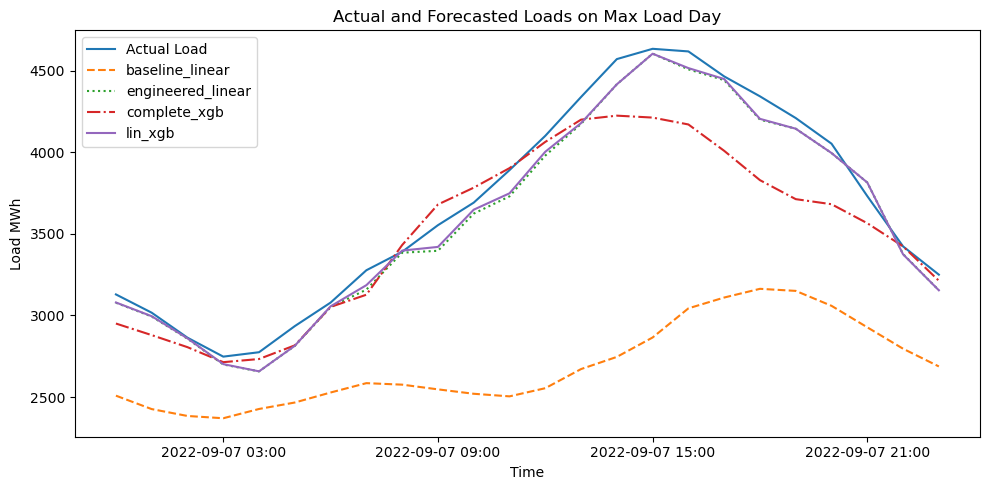

In [300]:
plt.figure(figsize=(10, 5))

plt.plot(max_load_date_predictions["timestamp"], max_load_date_predictions["Actual Load"], label = "Actual Load", linestyle = "-")

model_names = ["baseline_linear", "engineered_linear", "complete_xgb", "lin_xgb"]
linestyles = ["--", ":", "-.", "-"]

for i, model_name in enumerate(model_names):
    plt.plot(max_load_date_predictions["timestamp"], max_load_date_predictions[model_name + "_load"], label = model_name, linestyle = linestyles[i])

plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))

plt.xlabel("Time")
plt.ylabel("Load MWh")
plt.title("Actual and Forecasted Loads on Max Load Day")

plt.tight_layout()
plt.legend()

The above plot illustrates model performance on the single highest-load day in the dataset, September 7th, 2022. The baseline linear model performs the worst, consistently underpredicting demand by approximately 500–1500 MWh throughout the day and failing to correctly capture the timing of the peak. The remaining models accurately identify the timing of the peak load; however, the standalone XGBoost model still underestimates peak demand by roughly 300 MWh. In contrast, both the engineered linear model and the engineered linear model augmented with XGBoost residual learning closely track the actual load profile, including peak magnitude and intra-day shape.